In [2]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hugoaslm/fm-change-detection-benchmark.git"
BRANCH = "main"
REPO_DIR = Path("/content/fmcd-selection")
ZIP_PATH = Path("/content/drive/MyDrive/datasets/LEVIR-CD256.zip")
EXTRACT_DIR = Path("/content/datasets/levir-cd-256")
SELECTION_DRIVE_DIR = Path("/content/drive/MyDrive/fm-change-detection/selection")
FINAL_DRIVE_DIR = Path("/content/drive/MyDrive/fm-change-detection/final-test")


RUN_SELECTION = False
RUN_FINAL_TEST = False
RUN_FRONTIER = True

if (REPO_DIR / ".git").is_dir():
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", BRANCH], check=True)
elif REPO_DIR.exists():
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git clone; rename or remove it.")
else:
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "--branch",
            BRANCH,
            REPO_URL,
            str(REPO_DIR),
        ],
        check=True,
    )

os.chdir(REPO_DIR)
print("Repository:", REPO_DIR)
subprocess.run(["git", "log", "-1", "--oneline"], check=True)

Repository: /content/fmcd-selection


CompletedProcess(args=['git', 'log', '-1', '--oneline'], returncode=0)

In [3]:
import importlib
import sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "--no-cache-dir", "-q", "-e", ".[dev]"], check=True
)


sys.path.insert(0, str(REPO_DIR / "src"))
for module_name in list(sys.modules):
    if module_name == "fm_change_detection" or module_name.startswith("fm_change_detection."):
        del sys.modules[module_name]
importlib.invalidate_caches()
import fm_change_detection

source_path = Path(fm_change_detection.__file__).resolve()
print("Imported package:", source_path)
assert str(source_path).startswith(str(REPO_DIR)), "Python imported a stale package checkout."

help_result = subprocess.run(
    [sys.executable, "-m", "fm_change_detection.cli", "--help"],
    check=True,
    capture_output=True,
    text=True,
)
print(help_result.stdout)
assert "select" in help_result.stdout, "The checked-out repository does not contain fmcd select."

Imported package: /content/fmcd-selection/src/fm_change_detection/__init__.py
[CLI] launching fmcd pid=2448 argv=['/content/fmcd-selection/src/fm_change_detection/cli.py', '--help']
usage: fmcd [-h]
            {smoke,validate-data,extract,evaluate,select,benchmark,robustness,report,frontier}
            ...

Foundation Model Change Detection Benchmark CLI (v0.1)

positional arguments:
  {smoke,validate-data,extract,evaluate,select,benchmark,robustness,report,frontier}
                        Available commands
    smoke               Run CPU synthetic end-to-end smoke test
    validate-data       Validate LEVIR-CD directory layout and split lists
    extract             Pre-extract and cache features for an encoder
    evaluate            Evaluate single encoder, layer, and score method
    select              Select one layer and score per encoder using
                        train/validation data only
    benchmark           Run full benchmark across all configured
                

In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
assert torch.cuda.is_available(), "Switch this Colab runtime to a GPU before selection."

subprocess.run([sys.executable, "-m", "fm_change_detection.cli", "smoke"], check=True)
subprocess.run([sys.executable, "-m", "pytest", "-q"], check=True)

PyTorch: 2.11.0+cu128
CUDA available: True
Device: NVIDIA L4


CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q'], returncode=0)

In [5]:
import shutil

from google.colab import drive

drive.mount("/content/drive")
assert ZIP_PATH.is_file(), f"Dataset ZIP not found: {ZIP_PATH}"


def find_dataset_root(search_root: Path):
    paths = [search_root, *search_root.rglob("*")]
    return next(
        (
            path
            for path in paths
            if path.is_dir() and all((path / name).is_dir() for name in ("A", "B", "label", "list"))
        ),
        None,
    )


DATA_ROOT = find_dataset_root(EXTRACT_DIR) if EXTRACT_DIR.exists() else None
if DATA_ROOT is None:
    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)
    EXTRACT_DIR.mkdir(parents=True)
    print("Extracting LEVIR-CD256.zip...")
    shutil.unpack_archive(str(ZIP_PATH), str(EXTRACT_DIR))
    DATA_ROOT = find_dataset_root(EXTRACT_DIR)

assert DATA_ROOT is not None, "Could not locate A/, B/, label/, and list/ after extraction."
print("Dataset root:", DATA_ROOT)

subprocess.run(
    [
        sys.executable,
        "-m",
        "fm_change_detection.cli",
        "validate-data",
        "--root",
        str(DATA_ROOT),
    ],
    check=True,
)

Mounted at /content/drive
Extracting LEVIR-CD256.zip...
Dataset root: /content/datasets/levir-cd-256/LEVIR-CD256


CompletedProcess(args=['/usr/bin/python3', '-m', 'fm_change_detection.cli', 'validate-data', '--root', '/content/datasets/levir-cd-256/LEVIR-CD256'], returncode=0)

In [6]:
SELECTION_DIR = REPO_DIR / "outputs" / "selection"
selection_artifact_names = (
    "candidates.csv",
    "selection.json",
    "selection.md",
    "final_selected.yaml",
)

if RUN_SELECTION:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "fm_change_detection.cli",
            "select",
            "--config",
            "configs/selection.yaml",
            "--data-root",
            str(DATA_ROOT),
            "--device",
            "cuda",
        ],
        check=True,
    )
else:
    SELECTION_DIR.mkdir(parents=True, exist_ok=True)
    missing = [
        name for name in selection_artifact_names if not (SELECTION_DRIVE_DIR / name).is_file()
    ]
    assert not missing, (
        f"Missing saved selection artifacts in {SELECTION_DRIVE_DIR}: {missing}. "
        "Upload them there or set RUN_SELECTION=True."
    )
    for name in selection_artifact_names:
        shutil.copy2(SELECTION_DRIVE_DIR / name, SELECTION_DIR / name)
    print("Restored the inspected validation selection from:", SELECTION_DRIVE_DIR)

Restored the inspected validation selection from: /content/drive/MyDrive/fm-change-detection/selection


In [10]:
from IPython.display import Markdown, display

required_artifacts = [SELECTION_DIR / name for name in selection_artifact_names]
assert all(path.is_file() for path in required_artifacts), "Selection artifacts are incomplete."

display(Markdown((SELECTION_DIR / "selection.md").read_text()))
print("\n--- Frozen candidate configuration ---\n")
print((SELECTION_DIR / "final_selected.yaml").read_text())

# Validation-only representation selection

Selection criterion: validation average precision (tie-breakers: AUROC, calibrated F1).
The test split was not loaded or evaluated.

| Selected | Encoder | Layer | Score | Val AP | Val AUROC | Val F1 | Val IoU |
|---|---|---|---|---:|---:|---:|---:|
| ✓ | `dinov2_vits14` | `block3` | `cosine` | 0.2508 | 0.9168 | 0.3499 | 0.2120 |
|  | `dinov2_vits14` | `block3` | `standardized_euclidean` | 0.2093 | 0.8980 | 0.3035 | 0.1789 |
|  | `dinov2_vits14` | `block12` | `standardized_euclidean` | 0.2074 | 0.8902 | 0.3155 | 0.1873 |
|  | `dinov2_vits14` | `block6` | `cosine` | 0.2002 | 0.8917 | 0.3074 | 0.1816 |
|  | `dinov2_vits14` | `block9` | `cosine` | 0.1957 | 0.8797 | 0.3033 | 0.1788 |
|  | `dinov2_vits14` | `block6` | `standardized_euclidean` | 0.1736 | 0.8744 | 0.2721 | 0.1575 |
|  | `dinov2_vits14` | `block12` | `cosine` | 0.1666 | 0.8694 | 0.2840 | 0.1655 |
|  | `dinov2_vits14` | `block9` | `standardized_euclidean` | 0.1261 | 0.8398 | 0.2303 | 0.1302 |
| ✓ | `resnet50_imagenet` | `layer3` | `cosine` | 0.2002 | 0.8987 | 0.3027 | 0.1784 |
|  | `resnet50_imagenet` | `layer2` | `cosine` | 0.1917 | 0.8885 | 0.2892 | 0.1690 |
|  | `resnet50_imagenet` | `layer4` | `cosine` | 0.1436 | 0.8205 | 0.2340 | 0.1325 |
|  | `resnet50_imagenet` | `layer2` | `standardized_euclidean` | 0.1316 | 0.8435 | 0.2190 | 0.1229 |
|  | `resnet50_imagenet` | `layer3` | `standardized_euclidean` | 0.0959 | 0.7907 | 0.1756 | 0.0962 |
|  | `resnet50_imagenet` | `layer4` | `standardized_euclidean` | 0.0465 | 0.5817 | 0.0992 | 0.0522 |
| ✓ | `resnet50_s2_moco` | `layer3` | `cosine` | 0.1935 | 0.8743 | 0.2905 | 0.1699 |
|  | `resnet50_s2_moco` | `layer4` | `cosine` | 0.1812 | 0.8489 | 0.2933 | 0.1718 |
|  | `resnet50_s2_moco` | `layer3` | `standardized_euclidean` | 0.1384 | 0.8379 | 0.2304 | 0.1302 |
|  | `resnet50_s2_moco` | `layer2` | `cosine` | 0.1376 | 0.7955 | 0.2256 | 0.1272 |
|  | `resnet50_s2_moco` | `layer2` | `standardized_euclidean` | 0.1223 | 0.8201 | 0.2086 | 0.1164 |
|  | `resnet50_s2_moco` | `layer4` | `standardized_euclidean` | 0.1067 | 0.7426 | 0.1961 | 0.1087 |
| ✓ | `rgb_pixels` | `input` | `cosine` | 0.0453 | 0.5448 | 0.0932 | 0.0489 |



--- Frozen candidate configuration ---

dataset:
  name: levir_cd
  root: /content/datasets/levir-cd-256/LEVIR-CD256
  tile_size: 256
  input_size: 252
  seed: 42
encoders:
- name: rgb_pixels
  checkpoint: none
  layers:
  - input
  scores:
  - cosine
- name: resnet50_imagenet
  checkpoint: DEFAULT
  layers:
  - layer3
  scores:
  - cosine
- name: resnet50_s2_moco
  checkpoint: torchgeo_ssl4eo_s12_rgb_moco_efd9723
  layers:
  - layer3
  scores:
  - cosine
- name: dinov2_vits14
  checkpoint: vit_small_patch14_dinov2.lvd142m
  layers:
  - block3
  scores:
  - cosine
scoring:
  methods:
  - cosine
  - standardized_euclidean
thresholds:
  methods:
  - unlabeled
  - calibrated
bootstrap:
  num_resamples: 0
  confidence_level: 0.95
  seed: 42
runtime:
  device: auto
  max_train_samples: null
  max_val_samples: null
  max_test_samples: null
  cache_dtype: float16
output_dir: outputs/final_results
cache_dir: outputs/cache



In [ ]:
SELECTION_DRIVE_DIR.mkdir(parents=True, exist_ok=True)

for source in required_artifacts:
    shutil.copy2(source, SELECTION_DRIVE_DIR / source.name)

archive_path = shutil.make_archive("/content/validation_selection_artifacts", "zip", SELECTION_DIR)
print("Saved persistent artifacts to:", SELECTION_DRIVE_DIR)
print("Created downloadable archive:", archive_path)

In [ ]:
from google.colab.files import download

download("/content/validation_selection_artifacts.zip")

In [7]:
import json

import yaml

selection_record = json.loads((SELECTION_DIR / "selection.json").read_text())
final_config = yaml.safe_load((SELECTION_DIR / "final_selected.yaml").read_text())

assert selection_record["accessed_splits"] == ["train", "val"]
assert final_config["runtime"]["max_test_samples"] is None
assert final_config["bootstrap"]["num_resamples"] == 0

recorded_winners = {
    (row["encoder"], row["layer"], row["score"]) for row in selection_record["selected"]
}
configured_winners = {
    (encoder["name"], encoder["layers"][0], encoder["scores"][0])
    for encoder in final_config["encoders"]
}
assert configured_winners == recorded_winners, "Frozen YAML does not match selection.json."
assert len(configured_winners) == 4, "Expected one frozen candidate per representation family."

print("Frozen candidates verified:")
for candidate in sorted(configured_winners):
    print(" -", candidate)
print("Selection commit:", selection_record["git_commit"])

Frozen candidates verified:
 - ('dinov2_vits14', 'block3', 'cosine')
 - ('resnet50_imagenet', 'layer3', 'cosine')
 - ('resnet50_s2_moco', 'layer3', 'cosine')
 - ('rgb_pixels', 'input', 'cosine')
Selection commit: a5341fe


In [ ]:
if not RUN_FINAL_TEST:
    print("Final test is disabled. Set RUN_FINAL_TEST=True only after inspecting the selection.")
else:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "fm_change_detection.cli",
            "benchmark",
            "--config",
            str(SELECTION_DIR / "final_selected.yaml"),
            "--data-root",
            str(DATA_ROOT),
            "--device",
            "cuda",
        ],
        check=True,
    )

In [ ]:
if RUN_FINAL_TEST:
    import pandas as pd

    FINAL_RESULTS_DIR = REPO_DIR / "outputs" / "final_results"
    FINAL_REPORT = REPO_DIR / "reports" / "benchmark.md"
    result_files = sorted(FINAL_RESULTS_DIR.glob("*.json"))
    assert len(result_files) == 8, f"Expected 8 result JSON files, found {len(result_files)}."

    test_count = sum(
        1 for line in (DATA_ROOT / "list" / "test.txt").read_text().splitlines() if line.strip()
    )
    records = [json.loads(path.read_text()) for path in result_files]
    assert all(record["num_images"] == test_count for record in records)
    assert all(record["max_test_samples"] is None for record in records)
    assert len({record["manifest_hash"] for record in records}) == 1

    summary = pd.read_csv(FINAL_RESULTS_DIR / "summary.csv")
    display(
        summary[
            [
                "encoder",
                "layer",
                "score",
                "threshold_method",
                "average_precision",
                "auroc",
                "f1",
                "iou",
            ]
        ].sort_values(["threshold_method", "average_precision"], ascending=[True, False])
    )
    display(Markdown(FINAL_REPORT.read_text()))
    print(f"Verified complete test evaluation on {test_count} image pairs.")

In [ ]:
if RUN_FINAL_TEST:
    FINAL_DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    drive_results = FINAL_DRIVE_DIR / "results"
    if drive_results.exists():
        shutil.rmtree(drive_results)
    shutil.copytree(FINAL_RESULTS_DIR, drive_results)
    shutil.copy2(FINAL_REPORT, FINAL_DRIVE_DIR / "benchmark.md")
    shutil.copy2(SELECTION_DIR / "selection.json", FINAL_DRIVE_DIR / "selection.json")
    shutil.copy2(SELECTION_DIR / "final_selected.yaml", FINAL_DRIVE_DIR / "final_selected.yaml")

    archive_root = Path("/content/final_test_artifacts")
    if archive_root.exists():
        shutil.rmtree(archive_root)
    shutil.copytree(FINAL_DRIVE_DIR, archive_root)
    final_archive = shutil.make_archive("/content/final_test_artifacts", "zip", archive_root)
    print("Saved persistent final artifacts to:", FINAL_DRIVE_DIR)
    print("Created downloadable archive:", final_archive)

In [ ]:
if RUN_FINAL_TEST:
    download("/content/final_test_artifacts.zip")

In [8]:
if not RUN_FRONTIER:
    print("Frontier is disabled. Set RUN_FRONTIER=True after the final test is frozen.")
else:
    import subprocess

    proc = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "fm_change_detection.cli",
            "frontier",
            "--config",
            "configs/detectability.yaml",
            "--data-root",
            str(DATA_ROOT),
            "--device",
            "cuda",
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.stdout.close()
    returncode = proc.wait()
    assert returncode == 0, f"frontier subprocess failed with exit code {returncode}"

[CLI] launching fmcd pid=3549 argv=['/content/fmcd-selection/src/fm_change_detection/cli.py', 'frontier', '--config', 'configs/detectability.yaml', '--data-root', '/content/datasets/levir-cd-256/LEVIR-CD256', '--device', 'cuda']
[FRONTIER] Running controlled-change detectability frontier...
[FRONTIER] loading samples: val=1024 test=2048...
[FRONTIER] loaded 1024 val / 2048 test samples (19s)
[FRONTIER] device=cuda encoders=['rgb_pixels', 'resnet50_imagenet', 'resnet50_s2_moco', 'dinov2_vits14'] val=1024 test=2048 areas=[0.01, 0.04, 0.16] magnitudes=[0.05, 0.1, 0.2, 0.4] batch_size=32 rss=5526MB
[FRONTIER] encoder 1/4: rgb_pixels layer=input
[FRONTIER]   preload val: encoding 1024/1024 samples (batch_size=32)
[FRONTIER]   preload val: 32/1024 samples (0s, 123 samples/s)
[FRONTIER]   preload val: 64/1024 samples (0s, 177 samples/s)
[FRONTIER]   preload val: 96/1024 samples (0s, 208 samples/s)
[FRONTIER]   preload val: 128/1024 samples (1s, 227 samples/s)
[FRONTIER]   preload val: 160/102

# Controlled-change detectability frontier

Synthetic additive changes of known magnitude and spatial extent are injected into regions of the T2 timestamp that the real labels mark as unchanged. Ground truth is exactly the injected region. Thresholds are fitted on the clean validation split only.

## `dinov2_vits14` / `block3`

| Area | Magnitude | Samples | AP | AUROC | F1 (calib) | IoU (calib) | FPR (calib) |
|---|---:|---:|---:|---:|---:|---:|---:|
| 0.010 | 0.050 | 2048 | 0.0956 | 0.5307 | 0.0968 | 0.0508 | 0.1189 |
| 0.010 | 0.100 | 2048 | 0.1114 | 0.5991 | 0.1151 | 0.0611 | 0.1208 |
| 0.010 | 0.200 | 2048 | 0.1510 | 0.7051 | 0.1828 | 0.1006 | 0.1288 |
| 0.010 | 0.400 | 2048 | 0.2497 | 0.8159 | 0.3414 | 0.2059 | 0.1515 |
| 0.040 | 0.050 | 2040 | 0.2165 | 0.5149 | 0.1338 | 0.0717 | 0.1142 |
| 0.040 | 0.100 | 2040 | 0.2349 | 0.5600 | 0.1476 | 0.0797 | 0.1168 |
| 0.040 | 0.200 | 2040 | 0.2759 | 0.6342 | 0.1982 | 0.1100 | 0.1260 |
| 0.040 | 0.400 | 2040 | 0.3491 | 0.7180 | 0.3364 | 0.2022 | 0.1506 |
| 0.160 | 0.050 | 1883 | 0.3956 | 0.4913 | 0.1141 | 0.0605 | 0.0907 |
| 0.160 | 0.100 | 1883 | 0.4074 | 0.5121 | 0.1244 | 0.0663 | 0.0937 |
| 0.160 | 0.200 | 1883 | 0.4331 | 0.5513 | 0.1595 | 0.0867 | 0.1034 |
| 0.160 | 0.400 | 1883 | 0.4688 | 0.5949 | 0.2452 | 0.1397 | 0.1281 |

## `resnet50_imagenet` / `layer3`

| Area | Magnitude | Samples | AP | AUROC | F1 (calib) | IoU (calib) | FPR (calib) |
|---|---:|---:|---:|---:|---:|---:|---:|
| 0.010 | 0.050 | 2048 | 0.0979 | 0.5325 | 0.1126 | 0.0596 | 0.1371 |
| 0.010 | 0.100 | 2048 | 0.1161 | 0.5960 | 0.1512 | 0.0818 | 0.1437 |
| 0.010 | 0.200 | 2048 | 0.1612 | 0.7033 | 0.2350 | 0.1332 | 0.1595 |
| 0.010 | 0.400 | 2048 | 0.2370 | 0.7891 | 0.3343 | 0.2007 | 0.1883 |
| 0.040 | 0.050 | 2040 | 0.2222 | 0.5232 | 0.1609 | 0.0875 | 0.1329 |
| 0.040 | 0.100 | 2040 | 0.2436 | 0.5699 | 0.1916 | 0.1059 | 0.1393 |
| 0.040 | 0.200 | 2040 | 0.2965 | 0.6570 | 0.2863 | 0.1671 | 0.1561 |
| 0.040 | 0.400 | 2040 | 0.3749 | 0.7351 | 0.4249 | 0.2697 | 0.1896 |
| 0.160 | 0.050 | 1883 | 0.3958 | 0.4907 | 0.1358 | 0.0729 | 0.1082 |
| 0.160 | 0.100 | 1883 | 0.4068 | 0.5105 | 0.1526 | 0.0826 | 0.1157 |
| 0.160 | 0.200 | 1883 | 0.4332 | 0.5520 | 0.2077 | 0.1159 | 0.1346 |
| 0.160 | 0.400 | 1883 | 0.4671 | 0.5943 | 0.3071 | 0.1814 | 0.1711 |

## `resnet50_s2_moco` / `layer3`

| Area | Magnitude | Samples | AP | AUROC | F1 (calib) | IoU (calib) | FPR (calib) |
|---|---:|---:|---:|---:|---:|---:|---:|
| 0.010 | 0.050 | 2048 | 0.1037 | 0.5415 | 0.1363 | 0.0731 | 0.1451 |
| 0.010 | 0.100 | 2048 | 0.1344 | 0.6126 | 0.1981 | 0.1099 | 0.1628 |
| 0.010 | 0.200 | 2048 | 0.2161 | 0.7339 | 0.2937 | 0.1721 | 0.2041 |
| 0.010 | 0.400 | 2048 | 0.3313 | 0.8246 | 0.3473 | 0.2102 | 0.2657 |
| 0.040 | 0.050 | 2040 | 0.2364 | 0.5380 | 0.2061 | 0.1149 | 0.1477 |
| 0.040 | 0.100 | 2040 | 0.2787 | 0.6004 | 0.2873 | 0.1678 | 0.1740 |
| 0.040 | 0.200 | 2040 | 0.3776 | 0.7060 | 0.4414 | 0.2832 | 0.2361 |
| 0.040 | 0.400 | 2040 | 0.4982 | 0.7922 | 0.5250 | 0.3559 | 0.3165 |
| 0.160 | 0.050 | 1883 | 0.4179 | 0.5173 | 0.1935 | 0.1071 | 0.1238 |
| 0.160 | 0.100 | 1883 | 0.4392 | 0.5424 | 0.2694 | 0.1557 | 0.1600 |
| 0.160 | 0.200 | 1883 | 0.4807 | 0.5901 | 0.4103 | 0.2581 | 0.2382 |
| 0.160 | 0.400 | 1883 | 0.5330 | 0.6446 | 0.5354 | 0.3656 | 0.3316 |

## `rgb_pixels` / `input`

| Area | Magnitude | Samples | AP | AUROC | F1 (calib) | IoU (calib) | FPR (calib) |
|---|---:|---:|---:|---:|---:|---:|---:|
| 0.010 | 0.050 | 2048 | 0.0856 | 0.4696 | 0.1320 | 0.0706 | 0.3816 |
| 0.010 | 0.100 | 2048 | 0.0841 | 0.4605 | 0.1281 | 0.0685 | 0.3816 |
| 0.010 | 0.200 | 2048 | 0.0848 | 0.4637 | 0.1329 | 0.0712 | 0.3815 |
| 0.010 | 0.400 | 2048 | 0.0897 | 0.4916 | 0.1503 | 0.0813 | 0.3815 |
| 0.040 | 0.050 | 2040 | 0.2050 | 0.4731 | 0.2512 | 0.1436 | 0.3750 |
| 0.040 | 0.100 | 2040 | 0.2020 | 0.4643 | 0.2459 | 0.1402 | 0.3750 |
| 0.040 | 0.200 | 2040 | 0.2036 | 0.4681 | 0.2537 | 0.1453 | 0.3749 |
| 0.040 | 0.400 | 2040 | 0.2140 | 0.4965 | 0.2825 | 0.1645 | 0.3749 |
| 0.160 | 0.050 | 1883 | 0.3920 | 0.4685 | 0.3538 | 0.2149 | 0.3764 |
| 0.160 | 0.100 | 1883 | 0.3875 | 0.4594 | 0.3459 | 0.2091 | 0.3763 |
| 0.160 | 0.200 | 1883 | 0.3902 | 0.4634 | 0.3580 | 0.2180 | 0.3761 |
| 0.160 | 0.400 | 1883 | 0.4050 | 0.4914 | 0.3983 | 0.2487 | 0.3762 |


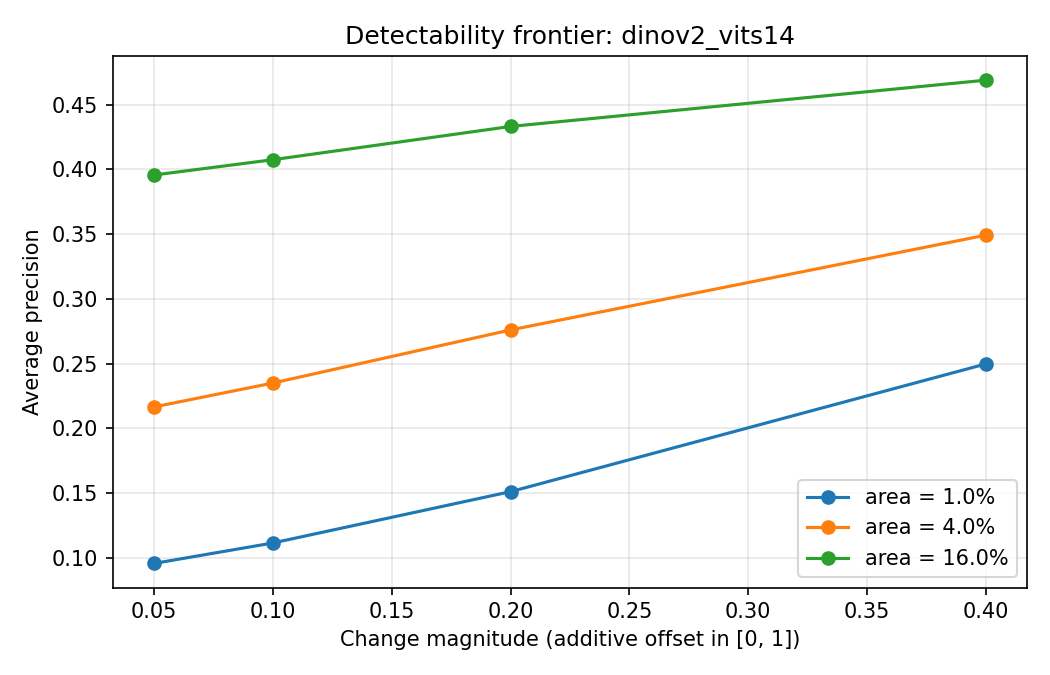

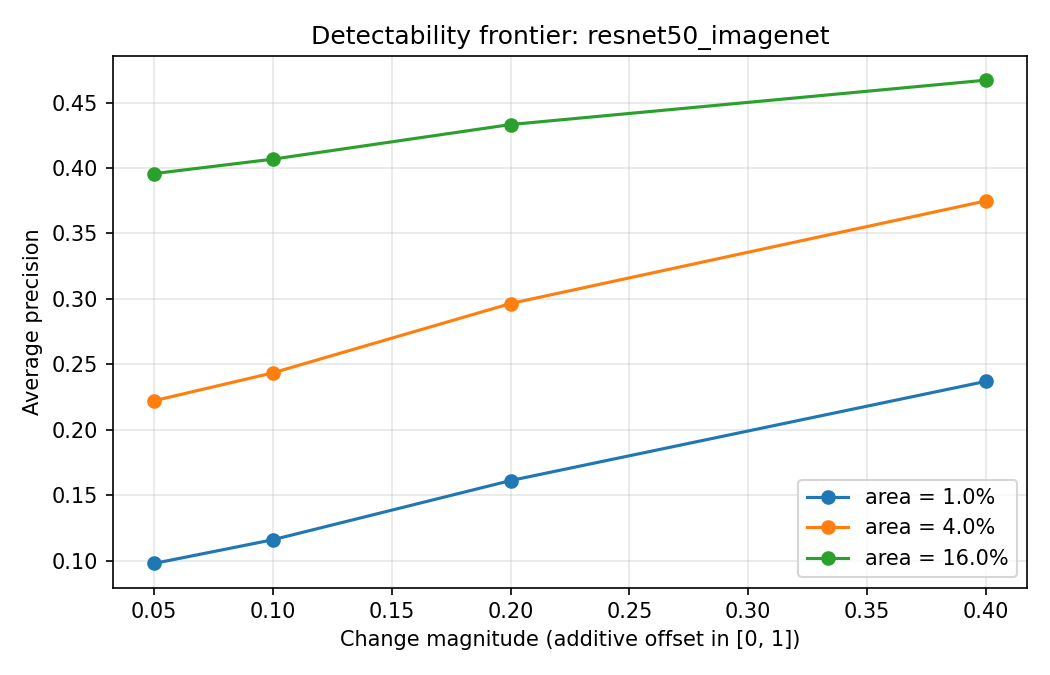

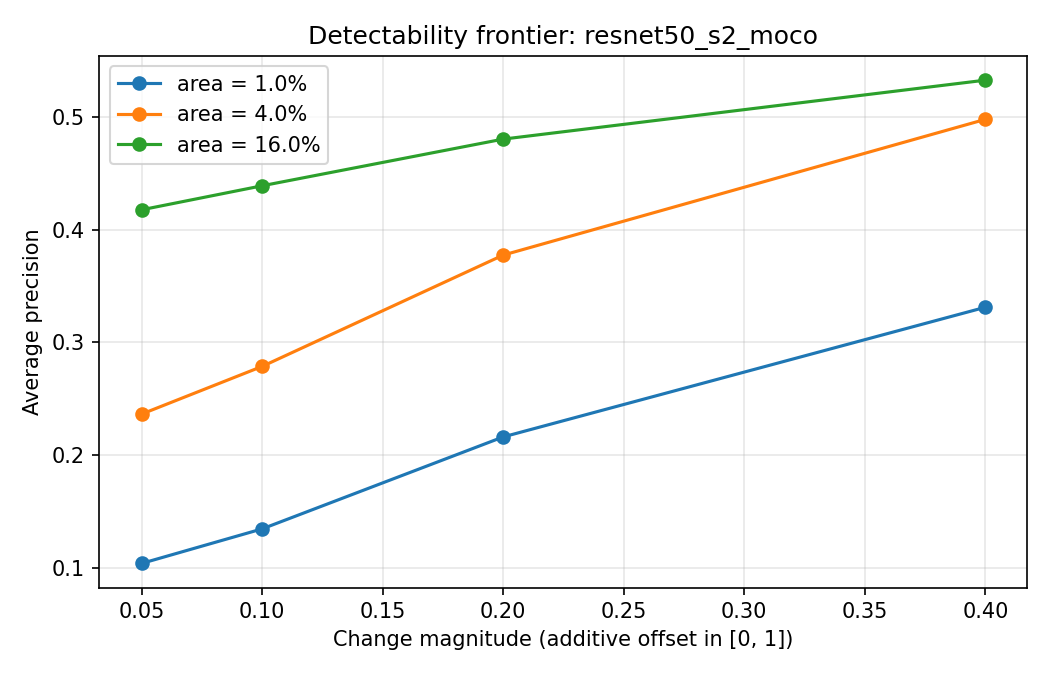

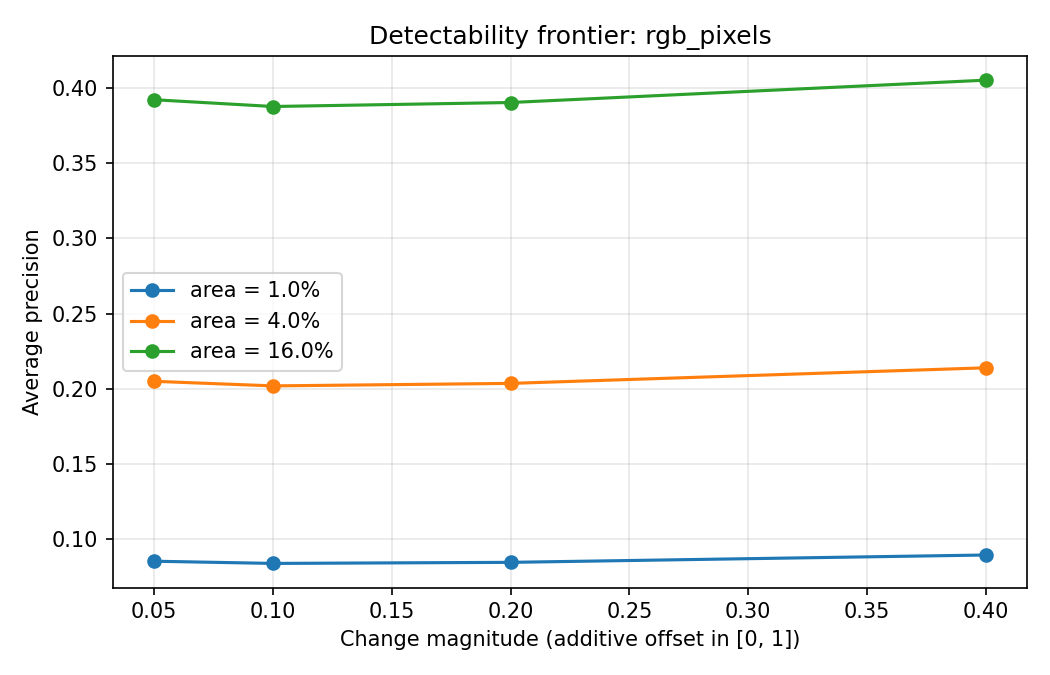

Saved persistent frontier artifacts to: /content/drive/MyDrive/fm-change-detection/frontier


In [11]:
if RUN_FRONTIER:
    from IPython.display import Image

    FRONTIER_REPORT = REPO_DIR / "reports" / "frontier.md"
    assert FRONTIER_REPORT.is_file(), "Frontier report missing after the run."
    display(Markdown(FRONTIER_REPORT.read_text()))

    fig_dir = REPO_DIR / "reports" / "figures"
    for fig in sorted(fig_dir.glob("frontier_*.png")):
        display(Image(filename=str(fig), width=720))

    FRONTIER_DRIVE_DIR = Path("/content/drive/MyDrive/fm-change-detection/frontier")
    FRONTIER_DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    drive_results = FRONTIER_DRIVE_DIR / "results"
    if drive_results.exists():
        shutil.rmtree(drive_results)
    shutil.copytree(REPO_DIR / "outputs" / "results_frontier", drive_results)
    shutil.copy2(FRONTIER_REPORT, FRONTIER_DRIVE_DIR / "frontier.md")
    drive_figs = FRONTIER_DRIVE_DIR / "figures"
    if drive_figs.exists():
        shutil.rmtree(drive_figs)
    shutil.copytree(fig_dir, drive_figs)
    print("Saved persistent frontier artifacts to:", FRONTIER_DRIVE_DIR)